In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv("base_snii-s191_2024.csv")

# Convertir monto a número
df["monto_anual"] = pd.to_numeric(df["monto_anual"], errors="coerce")

# Eliminar registros sin monto
df = df.dropna(subset=["monto_anual"])

# Clasificación por monto usando condiciones
def clasificar_monto(monto):
    if monto <= 447904.24:
        return "Candidato"
    elif monto <= 806934.03:
        return "Nivel I"
    elif monto <= 978077.17:
        return "Nivel II"
    elif monto <= 1567660.64:
        return "Nivel III"
    else:
        return "Emérito"

df["nivel_calculado"] = df["monto_anual"].apply(clasificar_monto)

# Ciclo para contar investigadores
contador = 0
for i in range(len(df)):
    contador += 1

print("Total de investigadores con monto válido:", contador)

# Resumen por nivel
resumen = df.groupby("nivel_distincion").agg(
    cantidad_investigadores=("cvu", "count"),
    monto_promedio=("monto_anual", "mean"),
    monto_maximo=("monto_anual", "max"),
    monto_minimo=("monto_anual", "min")
)

display(resumen)

Total de investigadores con monto válido: 41311


,cantidad_investigadores,monto_promedio,monto_maximo,monto_minimo
nivel_distincion,,,,
1,22249,263714.524308,806934.03,-38725.38
2,5933,336856.539543,978077.17,25229.60
3,2432,570794.181094,1567660.64,0.00
C,9994,146327.717670,447904.24,880.98
E,703,560385.712290,972539.40,92414.84


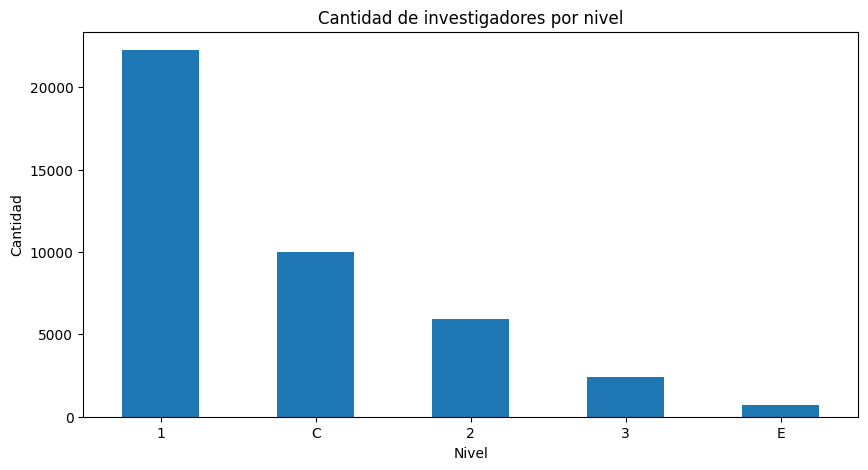

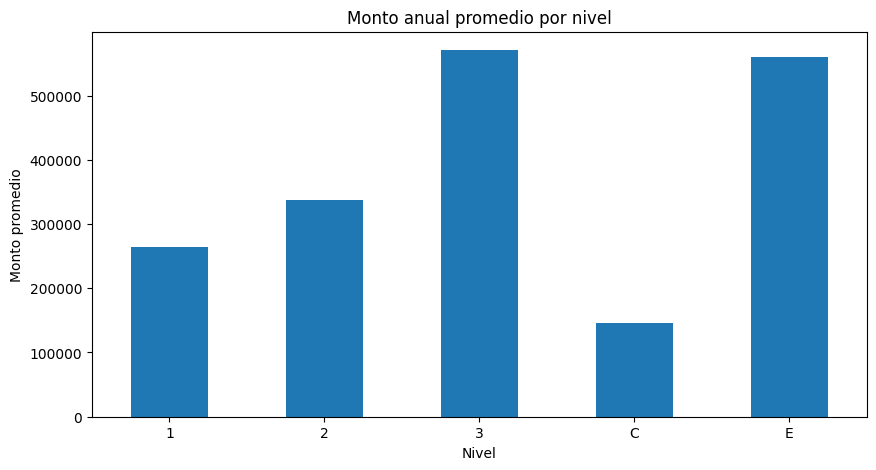

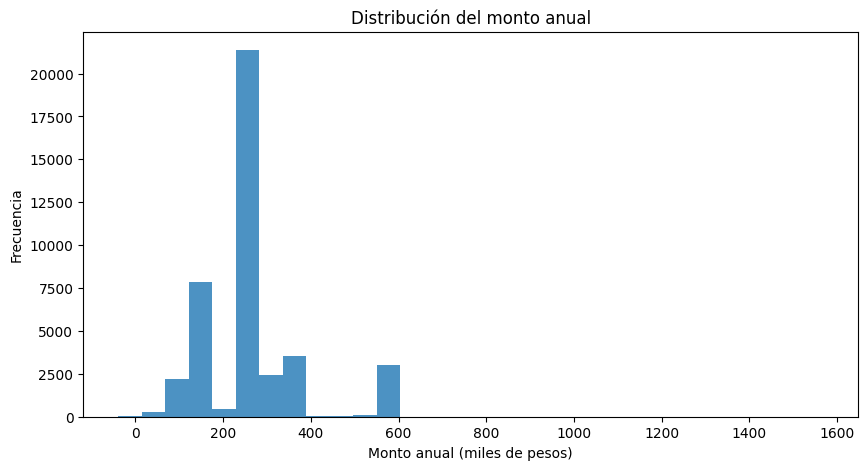

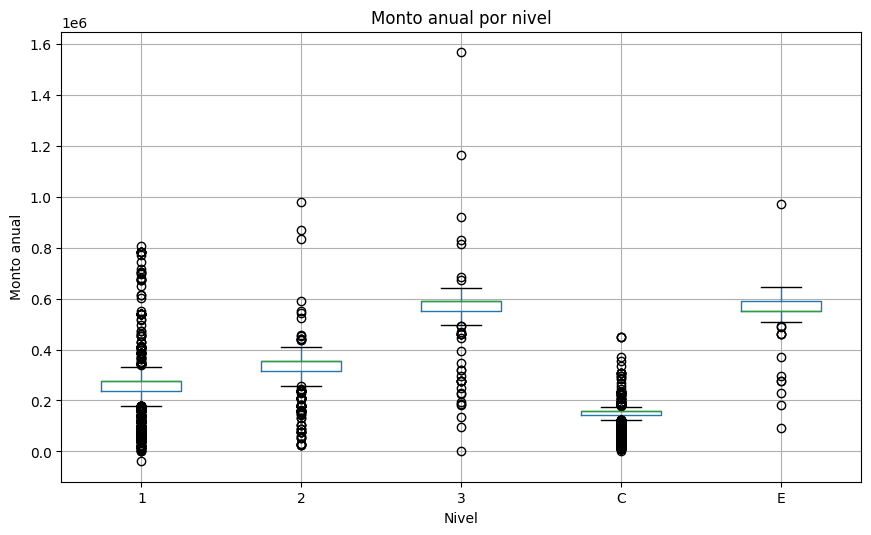

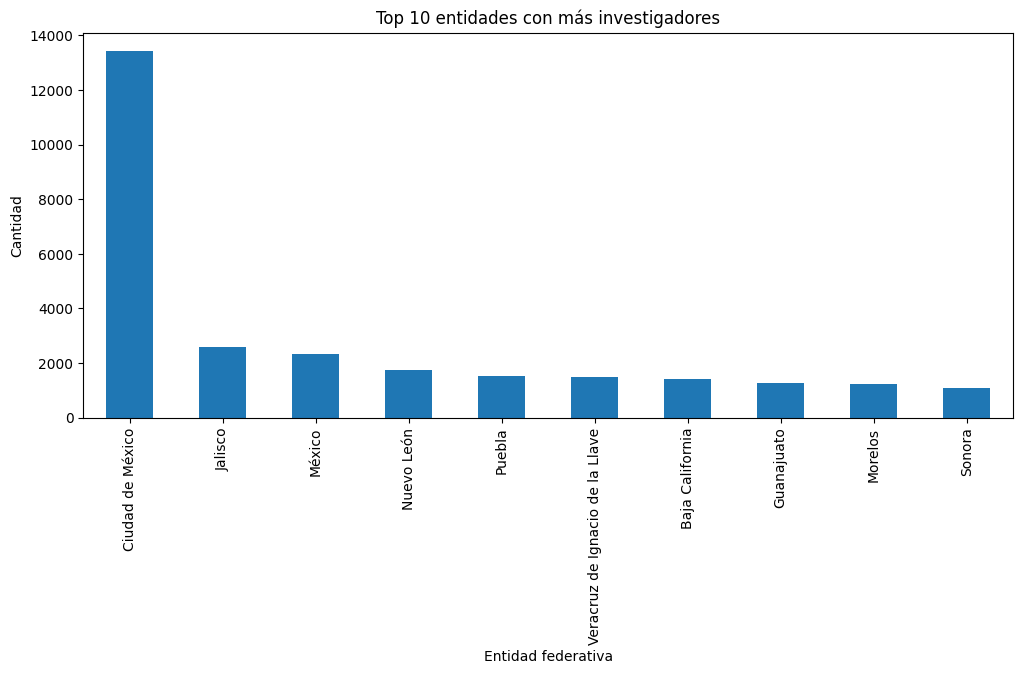

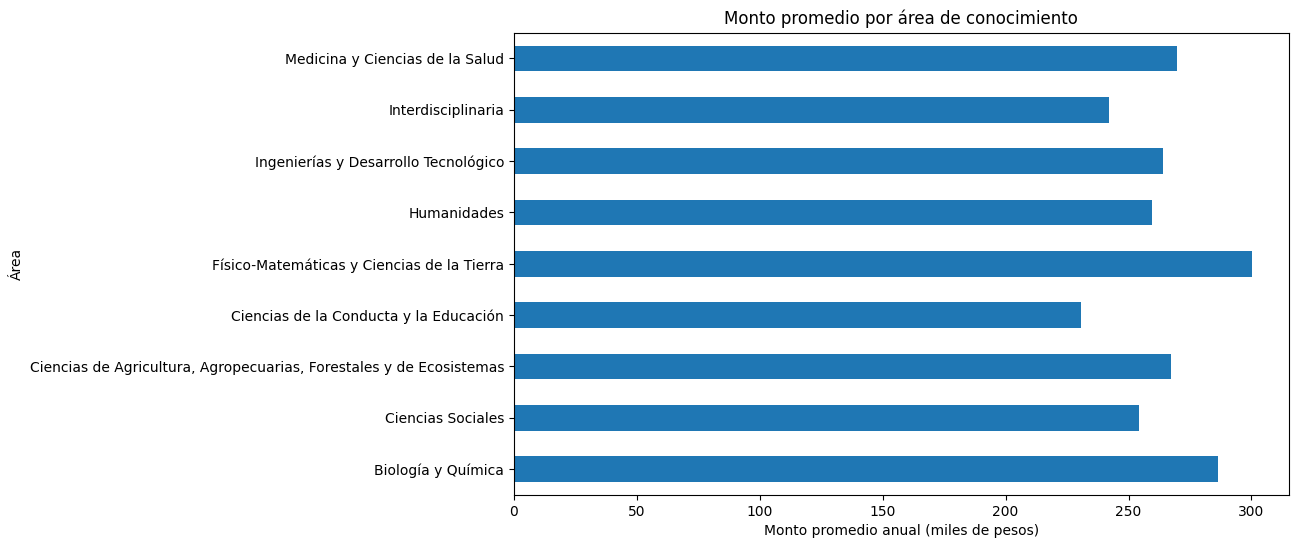

In [10]:
# 1. Gráfico de Barras: cantidad por nivel
df["nivel_distincion"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Cantidad de investigadores por nivel")
plt.xlabel("Nivel")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

# 2. Gráfico de Barras: monto promedio por nivel
df.groupby("nivel_distincion")["monto_anual"].mean().plot(kind="bar", figsize=(10,5))
plt.title("Monto anual promedio por nivel")
plt.xlabel("Nivel")
plt.ylabel("Monto promedio")
plt.xticks(rotation=0)
plt.show()

# 3. Histograma
(df["monto_anual"]/1000).plot.hist(bins=30,alpha=0.8,figsize=(10,5))
plt.title("Distribución del monto anual")
plt.xlabel("Monto anual (miles de pesos)")
plt.ylabel("Frecuencia")
plt.show()

# 4. Boxplot
df.boxplot(column="monto_anual", by="nivel_distincion", figsize=(10,6))
plt.title("Monto anual por nivel")
plt.suptitle("")
plt.xlabel("Nivel")
plt.ylabel("Monto anual")
plt.show()

# 5. Gráfico de Barras geográficas
df["entidad_federativa_inst_adscrip"].value_counts().head(10).plot(kind="bar", figsize=(12,5))
plt.title("Top 10 entidades con más investigadores")
plt.xlabel("Entidad federativa")
plt.ylabel("Cantidad")
# plt.xticks(rotation=45)
plt.show()

# 6. Gráfico de Barras por área de conocimiento
monto_area = df.groupby("area_conocimiento")["monto_anual"].mean()/ 1000
monto_area.plot(kind="barh",figsize=(10,6))
plt.title("Monto promedio por área de conocimiento")
plt.xlabel("Monto promedio anual (miles de pesos)")
plt.ylabel("Área")
plt.show()